# AutoML for Classification Model Screening

The following are the steps for using AutoML for a regression task:

_Note: Setting the flag for featurization= 'True' generates represents molecules using 5 representation techniques._ 

1. Requires an input pandas dataframe consisting of two columns:<br>
    * SMILES strings<br>
    * target class values<br>


2. If featurization = True, Molecules are represented as:<br>
    * Coulomb matrix<br>
    * RDKit Morgan (ECFP6 1024-bit) fingerprints<br>
    * MACCs keys<br>
    * RDKit hashed topological torsion<br>
    * RDKit molecular descriptors (all)<br>
    * Mordred molecular descriptors (currently using base Mordred)<br>


3. Screens through various classifier models:<br>
    * Single-core (runs regardless of multi_core value):
        * [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)<br>
        * [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)<br>
        * [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)<br>
        * [KNeighboursClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)<br>
    * Multi-core(set multi_core=True):
        * [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)<br>
        * [ChemML_MLP](https://hachmannlab.github.io/chemml/ipython_notebooks/ml_model.html) (if n_datapoints>500)<br>
        * (optional) [XGBClassifier](https://xgboost.readthedocs.io/en/latest/python/python_api.html)<br>
        * (optional) [LightGBM](https://lightgbm.readthedocs.io/en/stable/)

Yields 'n-best' models, with optimized hyperparamters.

The output_dir argument specifies a folder that will be created wherever the code is run from, containing the following directory tree:

<pre> &lt;output_dir&gt;/<br> |-- output.log<br> |-- scores.csv<br> |-- best_model/<br> |   |-- model.pkl # most non-MLP models<br> |   |-- model_chemml_model.json # MLP case (plus possible extra model files)<br> |   |-- scaler.pkl # present when scaler exists for chosen feature_key<br> |   |-- feature_order.json<br> |   |-- metadata.json<br> |-- .model_screener_artifacts/<br> |   |-- &lt;run_key_1&gt;/<br> |        |-- model.pkl # or MLP artifact files<br> |   |-- &lt;run_key_2&gt;/<br>... </pre>

## Load your data 

We are using ChemML's in-built dataset to demonstrate the minimum requirements to run AutoML.

In [1]:
import pandas as pd
from chemml.datasets import load_organic_density

In [2]:
molecules, target, dragon_subset = load_organic_density()
df=pd.concat([molecules, target], axis=1)
df = df.sample(200, random_state=42)
df

,smiles,density_Kg/m3
361,c1scc(n1)c1ncc(s1)c1c(ccc2c1cccc2)c1cncs1,1328.35
73,S1CC(SC(C1)C1CCCC1)c1cocc1c1ccccc1,1143.80
374,N1CNC(NC1)c1sccc1C1(CSCCS1)c1cccs1,1351.33
155,c1nc(c(s1)c1nsnc1)c1csc(n1)c1cccs1,1466.57
104,Oc1ccc2c(c1c1cocc1)c(ccc2)c1ccccn1,1207.67
...,...,...
248,Oc1ncc(c(c1)C)c1cnccn1,1195.16
145,Sc1cc2ccccc2c(c1)c1cnccc1c1cnccn1,1213.41
92,c1sc(c(c1)c1ncccc1c1nsnc1)c1ccc2c(c1)cccc2,1264.16
152,N1CNC(NC1)(N1CNC(NC1)c1cncs1)c1cccc2c1cccc2,1270.40


In [3]:
# Labeling data for classification instead of regression
# Note: This is just for demonstration purposes. In practice, you would want to use a regression model for predicting density.
df['density_class'] = pd.qcut(df['density_Kg/m3'], q=3, labels=range(3))

## Run autoML for a classification task

In [4]:
from chemml.autoML import ModelScreener

output_dir = "automl_results_class"

MS = ModelScreener(df, target="density_class", featurization=True, cache_features=False, smiles="smiles", 
                   screener_type="classifier", output_dir=output_dir)
scores = MS.screen_models(n_best=10, multi_core=False)



-------------------------ChemML AutoML Model Screening-------------------------

-------------------------Model screening started at Mon Aug 31 01:28:19 2026-------------------------



Converting SMILES to ChemML Molecule objects...



Converting SMILES to ChemML Molecule objects: 100%|██████████| 200/200 [00:06<00:00, 28.92it/s]



Generating Coulomb matrix representation...

featurizing molecules in batches of 12 ...
200/200 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step 
Merging batch features ...    [DONE]

Generating RDKit fingerprint representations...



Generating MACCS Fingerprints: 100%|██████████| 200/200 [00:00<00:00, 998.62molecule/s] 
Generating Hashed Topological Torsion Fingerprints: 100%|██████████| 200/200 [00:00<00:00, 8634.43molecule/s]
Generating Atom Pair Fingerprints: 100%|██████████| 200/200 [00:00<00:00, 9262.83molecule/s]



Generating RDKit descriptor representations...

Step 1: Normalizing molecule input


Step 2: Calculating RDKit descriptors: 100%|██████████| 200/200 [00:02<00:00, 95.34it/s]



Generating Mordred descriptor representations...

Step 1: Normalizing molecule input


Normalizing Molecule input: 100%|██████████| 200/200 [00:00<?, ?it/s]


Step 2/3: Optimizing geometry for 3D descriptor calculation


3D geometry already exists, loading geometry: 100%|██████████| 200/200 [00:00<?, ?it/s]

Step 3/3: Calculating Mordred descriptors



100%|██████████| 200/200 [00:06<00:00, 31.55it/s]



Cleaning feature sets to remove constant, highly correlated, low-variance, and complex features...

Feature set 'CoulombMatrix' cleaned: 25 features retained.

Feature set 'morganfingerprints_radius3' cleaned: 252 features retained.

Feature set 'MACCS_radius3' cleaned: 48 features retained.

Feature set 'hashedtopologicaltorsion_radius3' cleaned: 76 features retained.

Feature set 'hashedatompair_radius3' cleaned: 421 features retained.

Feature set 'rdkit_descriptors' cleaned: 90 features retained.

Feature set 'mord_descriptors' cleaned: 530 features retained.


-------------------------Run parameters-------------------------
  Featurization: True
  Multi_core: False
  Screener_type: classifier
  Number of datapoints: 200
  Note: Dataset <= 500 samples; MLP is excluded from screening due to inefficiency.

split done!
Single-core complete 


------------------------- Screening complete for feature set CoulombMatrix, time taken: 16.359 seconds -------------------------

split done!
S

In [5]:
scores

,Model,Accuracy,Recall,Precision,F1-score,time(seconds),parameters,Feature,run_key
27,LogisticRegression,0.8,0.793651,0.844444,0.797587,9.955029,"[{'C': 0.1, 'class_weight': None, 'dual': Fals...",mord_descriptors,LogisticRegression_mord_descriptors_324dd7b551...
26,KNeighborsClassifier,0.75,0.746032,0.811111,0.758371,6.259871,"[{'algorithm': 'auto', 'leaf_size': 30, 'metri...",mord_descriptors,KNeighborsClassifier_mord_descriptors_1e7fa7c1...
24,DecisionTreeClassifier,0.7,0.690476,0.763889,0.694444,3.405225,"[{'ccp_alpha': 0.0, 'class_weight': None, 'cri...",mord_descriptors,DecisionTreeClassifier_mord_descriptors_6a4d98...
19,LogisticRegression,0.65,0.642857,0.662963,0.646562,7.150034,"[{'C': 42.16315789473685, 'class_weight': None...",hashedatompair_radius3,LogisticRegression_hashedatompair_radius3_c444...
17,SVC,0.6,0.595238,0.604762,0.597691,2.851144,"[{'C': 0.0037926901907322525, 'break_ties': Fa...",hashedatompair_radius3,SVC_hashedatompair_radius3_ef5a1fb731b9493682d...
15,KNeighborsClassifier,0.55,0.563492,0.541667,0.545788,5.889152,"[{'algorithm': 'auto', 'leaf_size': 30, 'metri...",hashedtopologicaltorsion_radius3,KNeighborsClassifier_hashedtopologicaltorsion_...
16,DecisionTreeClassifier,0.5,0.507937,0.541667,0.505628,1.434301,"[{'ccp_alpha': 0.0, 'class_weight': None, 'cri...",hashedatompair_radius3,DecisionTreeClassifier_hashedatompair_radius3_...


## Validating AutoML-generated model

Since ChemML v1.3.4, AutoML outputs the best model and required scaler and feature order as easy-to-import files. A quick demonstration of the model loading workflow is given below:

In [6]:
import pickle
import json

with open(f'{output_dir}/best_model/metadata.json', 'r') as f:
    metadata = json.load(f)
with open(f'{output_dir}/best_model/explanation.json', 'r') as f:
    explanation = json.load(f)
with open(f'{output_dir}/best_model/feature_order.json', 'r') as f:
    feature_order = json.load(f)
with open(f"{output_dir}/best_model/model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
with open(f"{output_dir}/best_model/scaler.pkl", "rb") as f:
    loaded_scaler = pickle.load(f)

Metadata isn't necessary for model validation, but gives us a lot of context from the AutoML screening workflow.

In [7]:
metadata

{'artifact_schema_version': 1,
 'model_name': 'LogisticRegression',
 'feature_key': 'mord_descriptors',
 'run_key': 'LogisticRegression_mord_descriptors_324dd7b551dd4d0e89563c3fa79868b8',
 'screener_type': 'classifier',
 'parameters': {'C': 0.1,
  'class_weight': None,
  'dual': False,
  'fit_intercept': True,
  'intercept_scaling': 1,
  'l1_ratio': 0.0,
  'max_iter': 100,
  'n_jobs': None,
  'penalty': 'deprecated',
  'random_state': None,
  'solver': 'sag',
  'tol': 0.0001,
  'verbose': 0,
  'warm_start': False},
 'n_folds': 5,
 'n_datapoints': 200,
 'metrics': {'Accuracy': 0.8,
  'Recall': 0.7936507936507936,
  'Precision': 0.8444444444444444,
  'F1-score': 0.7975867269984916,
  'time(seconds)': 9.955028772354126},
 'model_serializer': 'pickle',
 'model_artifact_dir': 'model_artifact',
 'scaler_file': 'scaler.pkl',
 'feature_order_file': 'feature_order.json',
 'timestamp': 'Mon Aug 31 01:30:34 2026'}

Explanation gives the user a list of feature importances alongside feature names; while not necessary for validation, this is useful to understand what features the model is actually using

In [8]:
explanation

{'model_type': 'LogisticRegression',
 'explanation_type': 'linear.coef_',
 'importance_values': {'BCUTs-1l': 0.12080837896578821,
  'ATSC6s': 0.11705360020911237,
  'BCUTdv-1l': 0.11643211939895474,
  'MATS6s': 0.11176801885427924,
  'MIC0': -0.10732155496149466,
  'BCUTZ-1h': -0.10718923909200691,
  'VSA_EState7': 0.10557335217812619,
  'SM1_DzZ': -0.10481593783264181,
  'MIC2': -0.10150151886248547,
  'MDEC-22': 0.10067185163430138,
  'PEOE_VSA4': -0.10042496013838315,
  'Mor13': 0.09870373105961783,
  'IC0': -0.09707281423378299,
  'C2SP3': 0.09600380966243331,
  'Mor19': 0.09434981175135433,
  'IC2': -0.09216564338412887,
  'Mor23v': -0.08944319176524317,
  'WNSA4': 0.08883671204663847,
  'Mor11m': 0.08859302230665116,
  'nHetero': -0.08830107172063842,
  'Mor21': -0.0877983270264638,
  'nS': -0.0852109498551405,
  'MATS1s': 0.0849868365554287,
  'ATSC8i': -0.08486929913376605,
  'Mor11v': 0.0843377479785362,
  'PEOE_VSA6': 0.08371084437200652,
  'GATS3Z': 0.08314941767103975,
  'Z

feature_order ensures that the trained model sees features in the exact same order as trained.

In [9]:
feature_order[:5]

['ABC', 'ABCGG', 'nBase', 'SpDiam_A', 'nAromAtom']

In [10]:
from chemml.chem import Molecule
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tqdm
from chemml.chem import Mordred
from sklearn.svm import SVR

mol_objs_list = []
for i, smi in enumerate(tqdm.tqdm(df["smiles"], desc="Converting SMILES to ChemML Molecule objects")):
    mol = Molecule(smi, 'smiles')
    mol.hydrogens('add')
    try:
        mol.to_xyz('MMFF', maxIters=10000, mmffVariant='MMFF94s')
        mol_objs_list.append(mol)
    except Exception as e:
        print(f"\nUnable to process SMILES: {smi}; Error: {e}")
        # self.discarded_indices.append(i)
loaded_mols = mol_objs_list
features = Mordred(ignore_3D=False).represent(loaded_mols).drop(columns=['SMILES'])[feature_order].values
targets = df["density_class"].values


X_test = loaded_scaler.transform(features)

y_pred = loaded_model.predict(X_test)
y_pred_proba = loaded_model.predict_proba(X_test)

Converting SMILES to ChemML Molecule objects: 100%|██████████| 200/200 [00:06<00:00, 29.34it/s]


Step 1: Normalizing molecule input
Step 2/3: Optimizing geometry for 3D descriptor calculation
Step 3/3: Calculating Mordred descriptors


The loaded_model object can be treated just like any model object

In [11]:
loaded_model

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'sag'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties

In [12]:
targets[:5], y_pred[:5]

([2, 0, 2, 2, 0]
 Categories (3, int64): [0 < 1 < 2],
 array([2, 0, 2, 2, 0]))

In [13]:
from chemml.utils import classification_metrics
classification_metrics(targets, y_pred)

TP:  [65 66 65]
FP:  [0 3 1]
TN:  [131 130 131]
FN : [2 4 2]
Accuracy:  0.98
Precision:  [1.         0.95652174 0.98484848]
Recall:  [0.97014925 1.         0.97014925]
f1_score:  [0.98484848 0.97777778 0.97744361]
FPR:  [0.         0.02255639 0.00757576]
TPR:  [0.97014925 0.94285714 0.97014925]
                    0           1           2
TP          65.000000   66.000000   65.000000
TN         131.000000  130.000000  131.000000
FP           0.000000    3.000000    1.000000
FN           2.000000    4.000000    2.000000
precision    1.000000    0.956522    0.984848
recall       0.970149    1.000000    0.970149
f1_score     0.984848    0.977778    0.977444
TPR          0.970149    0.942857    0.970149
FPR          0.000000    0.022556    0.007576
TNR          1.000000    0.977444    0.992424
PPV          1.000000    0.956522    0.984848
NPV          0.984962    0.970149    0.984962
FNR          0.029851    0.057143    0.029851
FDR          0.000000    0.043478    0.015152


(np.float64(0.98),
       0     1     2
 0  65.0   1.0   1.0
 1   0.0  66.0   0.0
 2   0.0   2.0  65.0,
                     0           1           2
 TP          65.000000   66.000000   65.000000
 TN         131.000000  130.000000  131.000000
 FP           0.000000    3.000000    1.000000
 FN           2.000000    4.000000    2.000000
 precision    1.000000    0.956522    0.984848
 recall       0.970149    1.000000    0.970149
 f1_score     0.984848    0.977778    0.977444
 TPR          0.970149    0.942857    0.970149
 FPR          0.000000    0.022556    0.007576
 TNR          1.000000    0.977444    0.992424
 PPV          1.000000    0.956522    0.984848
 NPV          0.984962    0.970149    0.984962
 FNR          0.029851    0.057143    0.029851
 FDR          0.000000    0.043478    0.015152)

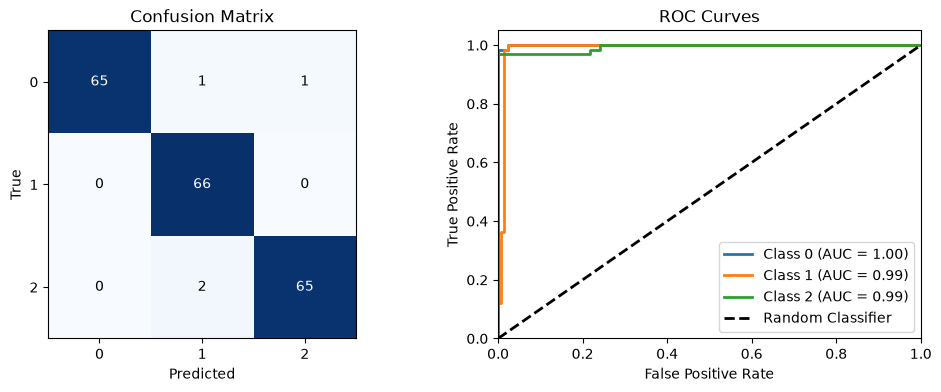

In [14]:
%matplotlib inline
from chemml.visualization import ClassificationPlots


plotter = ClassificationPlots().plot(targets, y_pred, y_pred_proba)
display(plotter)